⊹₊˚‧⋆.ೃ࿔*:･°⊹₊˚‧︵‿₊୨୧₊‿︵‧˚₊⊹⋆.ೃ࿔*:･°⊹₊˚‧⊹₊˚‧⋆.ೃ࿔:･°
# **ML - Fake News Detection**
⊹₊˚‧⋆.ೃ࿔*:･°⊹₊˚‧︵‿₊୨୧₊‿︵‧˚₊⊹⋆.ೃ࿔*:･°⊹₊˚‧⊹₊˚‧⋆.ೃ࿔:･°

Zenab✿

Fatima✿

Ushna✿

This notebook implements a complete machine learning pipeline for fake news detection.
It covers data preprocessing, feature engineering, model training, evaluation, comparison, and final model saving for deployment.

# --- Libraries ---
This cell imports all the required Python libraries for:

Data handling (pandas, numpy)

Text preprocessing (re, nltk)

Visualization (matplotlib, seaborn, wordcloud)

Machine learning (scikit-learn)

Model saving and loading (joblib)

Each library plays a specific role in building and evaluating the fake news detection system.

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_score, recall_score, f1_score, roc_auc_score)

import joblib
import shap


# --- Visualization Theme Setup ---
Seaborn / Pastel Theme

This section sets a soft pastel visualization theme using Seaborn and Matplotlib.
The purpose is to make plots visually clean, readable, and consistent throughout the notebook, especially for confusion matrices and ROC curves.

In [ ]:
sns.set_theme(
    style="whitegrid",
    palette="pastel",
    rc={
        "axes.facecolor": "#f9f7fc",
        "figure.facecolor": "#fdfcff",
        "grid.color": "#e6e0f0",
        "axes.edgecolor": "#cdb4db",
        "axes.labelcolor": "#6d597a",
        "xtick.color": "#6d597a",
        "ytick.color": "#6d597a",
        "text.color": "#6d597a",
        "axes.titleweight": "bold"
    }
)
plt.rcParams["font.family"] = "DejaVu Sans"

# --- NLTK Resource Downloadss ---


This cell downloads essential Natural Language Processing resources:

Stopwords

Tokenizers

WordNet for lemmatization

These resources are required for text cleaning and normalization.

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# --- Load datasets ---
Loading Real and Fake News Data

Two datasets are loaded:

True.csv → Real news articles

Fake.csv → Fake news articles

Each dataset is labeled:

0 for real news

1 for fake news

Both datasets are then merged and shuffled to remove any ordering bias.

In [ ]:
real_df = pd.read_csv(
    "True.csv",
    engine="python",
    on_bad_lines="skip"
)

fake_df = pd.read_csv(
    "Fake.csv",
    engine="python",
    on_bad_lines="skip"
)

real_df["label"] = 0
fake_df["label"] = 1
df = pd.concat([real_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


# --- Combine title + text ---
Combining Title and Article Text

The news title and article text are merged into a single column named content.
This provides richer textual information for the model.
Unnecessary columns such as date are removed.

In [ ]:
df["content"] = df["title"] + " " + df["text"]
df = df.drop(columns=["title", "text", "date"])

### Columns:

subject → category of the news

label → 0 = real, 1 = fake

content → combined title + text

cleaned_text → fully cleaned version (lowercase, no punctuation, lemmatized, stopwords removed)


---



### Dataset status:

44,889 rows

No missing values

Clean text ready for vectorization

# --- Clean text ---

Text Cleaning Function

This step prepares raw text for machine learning by:

Converting text to lowercase

Removing URLs, punctuation, and numbers

Tokenizing words

Removing stopwords

Applying lemmatization

Only meaningful and normalized text is kept for further processing.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = nltk.word_tokenize(text)
    return " ".join([lemmatizer.lemmatize(w) for w in words if w not in stop_words])




Apply Cleaning and Filter Data

In [ ]:
df["cleaned_text"] = df["content"].apply(clean_text)
df = df[df["cleaned_text"].str.len() > 20].reset_index(drop=True)

# --- Most Frequent Words ---

Top 20 most common words in fake news:

In [ ]:

from collections import Counter

fake_words = " ".join(df[df.label==1]["cleaned_text"]).split()
Counter(fake_words).most_common(20)


[('trump', 89438),
 ('said', 33957),
 ('president', 29561),
 ('people', 27195),
 ('one', 26087),
 ('u', 25840),
 ('state', 24259),
 ('would', 23827),
 ('obama', 21414),
 ('clinton', 21037),
 ('time', 19641),
 ('year', 19539),
 ('like', 19077),
 ('american', 18897),
 ('donald', 18637),
 ('video', 17687),
 ('republican', 17623),
 ('say', 16540),
 ('hillary', 16510),
 ('news', 15571)]

Top 20 most common words in real news:

In [ ]:
from collections import Counter

real_words = " ".join(df[df.label==0]["cleaned_text"]).split()
Counter(real_words).most_common(20)


[('said', 99076),
 ('trump', 60292),
 ('u', 51876),
 ('state', 38503),
 ('would', 31839),
 ('president', 29260),
 ('reuters', 29103),
 ('republican', 23983),
 ('year', 22873),
 ('government', 20412),
 ('house', 18482),
 ('new', 17792),
 ('also', 15965),
 ('party', 15710),
 ('united', 15640),
 ('people', 15461),
 ('election', 15415),
 ('official', 15171),
 ('told', 14286),
 ('country', 14245)]

# --- WordClouds ---

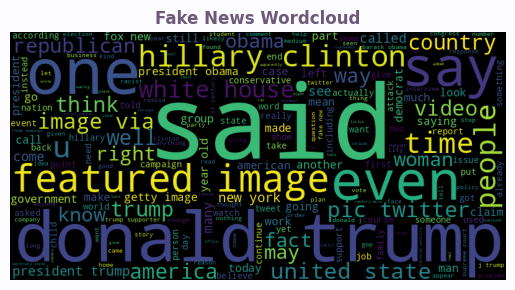

In [ ]:
from wordcloud import WordCloud

fake_wc = WordCloud(width=800, height=400).generate(" ".join(df[df.label==1]["cleaned_text"]))
plt.imshow(fake_wc)
plt.axis("off")
plt.title("Fake News Wordcloud")
plt.show()


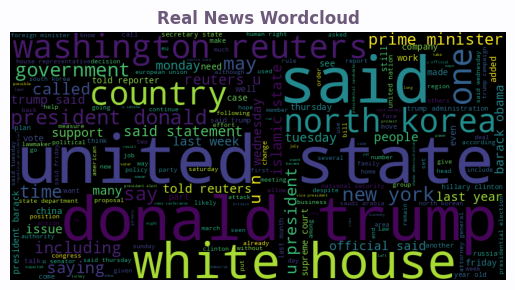

In [ ]:
real_wc = WordCloud(width=800, height=400).generate(" ".join(df[df.label==0]["cleaned_text"]))
plt.imshow(real_wc)
plt.axis("off")
plt.title("Real News Wordcloud")
plt.show()


# --- Train / Val / Test split ---

Dataset Splitting

The dataset is split into:

Training set (70%)

Validation set (15%)

Test set (15%)

Stratified sampling is used to maintain class balance across all splits.

In [ ]:
X = df["cleaned_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# --- TF-IDF ---
TF-IDF Vectorization

TF-IDF converts text into numerical features based on word importance.
Bigram features are also included to capture phrase-level information.

This step transforms raw text into a machine-readable format.

In [ ]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# --- Chi-square feature selection ---
Feature Selection using Chi-Square

Chi-square selects the most relevant features based on their statistical relationship with the target label.

This reduces dimensionality, removes noise, and improves model efficiency and performance.

In [ ]:
selector = SelectKBest(chi2, k=20000)
X_train_chi = selector.fit_transform(X_train_tfidf, y_train)
X_val_chi = selector.transform(X_val_tfidf)
X_test_chi = selector.transform(X_test_tfidf)

# --- MODELS TRAINING ---

Machine Learning Models

Multiple classification models are initialized:

Logistic Regression

Naive Bayes

Linear SVM

Passive Aggressive Classifier (PAC)

Random Forest

All models are stored in a dictionary to enable clean and scalable training using a loop.

In [ ]:
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(max_iter=5000, random_state=42),
    "PAC": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}


# --- Model Training ---

Training All Models

Each model is trained using the same feature set to ensure fair comparison.
Using a loop avoids repetitive code and keeps the notebook clean and modular.

In [ ]:
for name, mdl in models_dict.items():
    mdl.fit(X_train_chi, y_train)

# --- Model Evaluation function ---

Evaluation Function

This function evaluates models using:

Accuracy

Precision

Recall

F1-Score

ROC-AUC Score

It also plots the confusion matrix to visually analyze classification performance.

In [ ]:
def evaluate_model(name, model):
    y_val_pred = model.predict(X_val_chi)
    y_test_pred = model.predict(X_test_chi)

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_chi)[:,1]
    else:
        scores = model.decision_function(X_test_chi)

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.color_palette("pastel", as_cmap=True))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name} (Test Data)")
    plt.show()

    print(f"{name} Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"{name} Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-Score": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, scores)
    }

# --- Evaluate All Models & Comparison Table ---

All models are evaluated on validation and test data.
Their performance metrics are stored in a dataframe for easy comparison and analysis.

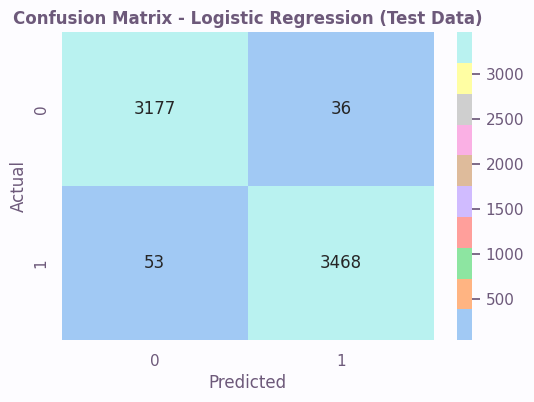

Logistic Regression Validation Accuracy: 0.9877
Logistic Regression Test Accuracy: 0.9868


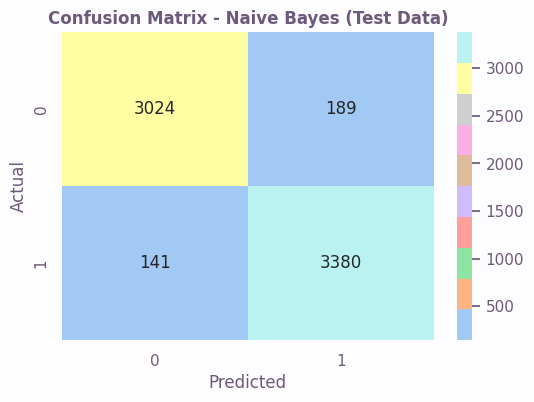

Naive Bayes Validation Accuracy: 0.9532
Naive Bayes Test Accuracy: 0.9510


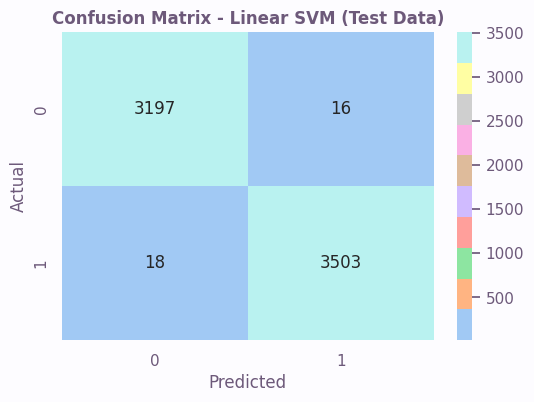

Linear SVM Validation Accuracy: 0.9966
Linear SVM Test Accuracy: 0.9950


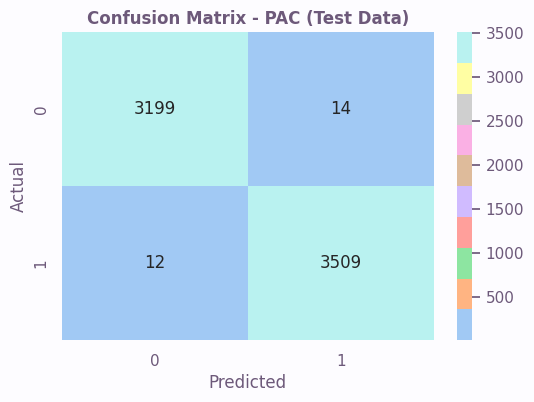

PAC Validation Accuracy: 0.9963
PAC Test Accuracy: 0.9961


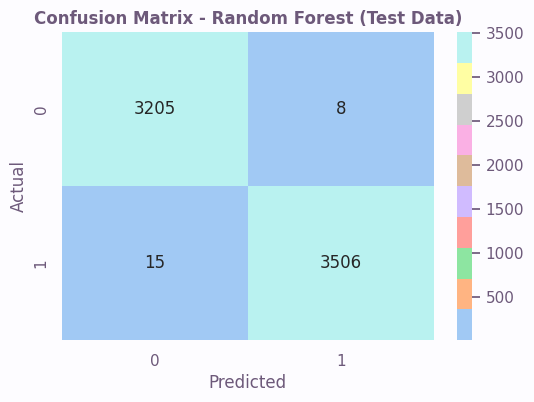

Random Forest Validation Accuracy: 0.9973
Random Forest Test Accuracy: 0.9966


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.986783,0.989726,0.984947,0.987331,0.998610
1,Naive Bayes,0.950995,0.947044,0.959955,0.953456,0.989578
2,Linear SVM,0.994951,0.995453,0.994888,0.995170,0.999618
3,PAC,0.996139,0.996026,0.996592,0.996309,0.999607
4,Random Forest,0.996584,0.997723,0.995740,0.996731,0.999927


In [ ]:
results_list = []
for name, mdl in models_dict.items():
    res = evaluate_model(name, mdl)
    results_list.append(res)

results_df = pd.DataFrame(results_list)
results_df

# --- ROC Curve Comparison ---
ROC Curve Visualization

ROC curves are plotted for all models to compare their ability to distinguish between real and fake news.

The Area Under Curve (AUC) provides a single-value performance comparison metric.

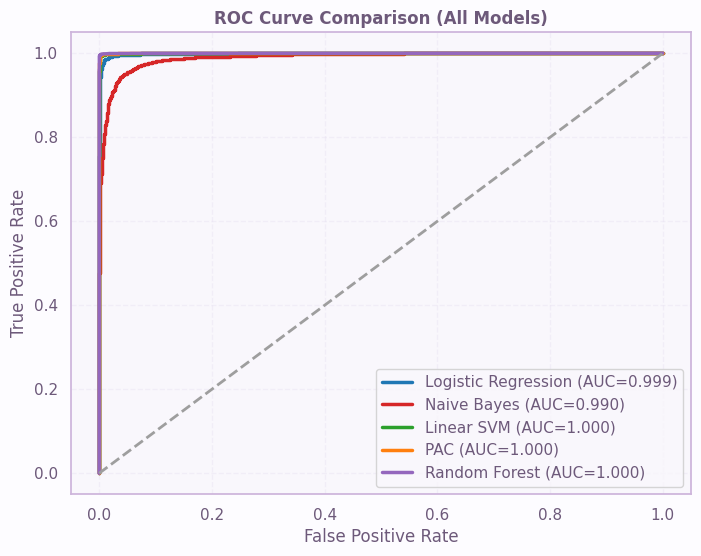

In [ ]:
plt.figure(figsize=(8,6))

roc_colors = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#ff7f0e",  # orange
    "#9467bd"   # purple
]

for (name, mdl), color in zip(models_dict.items(), roc_colors):
    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X_test_chi)[:, 1]
    else:
        scores = mdl.decision_function(X_test_chi)

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC={roc_auc:.3f})",
        color=color,
        linewidth=2.5,
        alpha=1
    )

plt.plot([0,1], [0,1], linestyle="--", color="#9e9e9e", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# --- Hyperparameter tuning ---
Grid Search Optimization

GridSearchCV is used to tune hyperparameters for:

Logistic Regression

Random Forest

This step helps identify the best parameters to improve model performance.

# Logistic Regression tuning

In [ ]:
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000), {"C":[0.01,0.1,1,10]}, cv=3, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train_chi, y_train)
print("Best LR params:", grid_lr.best_params_)

Best LR params: {'C': 10}


# Random Forest tuning

In [ ]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       {"n_estimators":[100,200,300], "max_depth":[None,10,20]},
                       cv=3, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train_chi, y_train)
print("Best RF params:", grid_rf.best_params_)


Best RF params: {'max_depth': None, 'n_estimators': 200}


# --- Train tuned Logistic Regression and Random Forest ---
 Use best hyperparameters found from GridSearchCV
## Tuned Logistic Regression

In [ ]:
best_lr = LogisticRegression(max_iter=2000, C=grid_lr.best_params_['C'])
best_lr.fit(X_train_chi, y_train)

LogisticRegression(C=10, max_iter=2000)

# Tuned Random Forest

In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=grid_rf.best_params_['n_estimators'],
    max_depth=grid_rf.best_params_['max_depth'],
    random_state=42
)
best_rf.fit(X_train_chi, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Evaluate Tuned Models

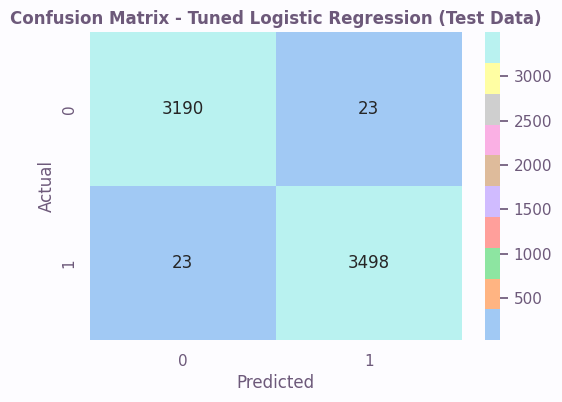

Tuned Logistic Regression Validation Accuracy: 0.9947
Tuned Logistic Regression Test Accuracy: 0.9932


{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.9931689931689932,
 'Precision': 0.9934677648395343,
 'Recall': 0.9934677648395343,
 'F1-Score': 0.9934677648395343,
 'ROC-AUC': np.float64(0.9994393162610747)}

In [ ]:
evaluate_model("Tuned Logistic Regression", best_lr)


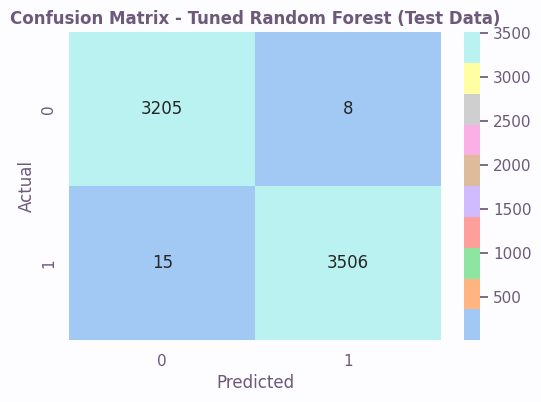

Tuned Random Forest Validation Accuracy: 0.9973
Tuned Random Forest Test Accuracy: 0.9966


{'Model': 'Tuned Random Forest',
 'Accuracy': 0.9965844965844965,
 'Precision': 0.9977233921457029,
 'Recall': 0.9957398466344788,
 'F1-Score': 0.996730632551528,
 'ROC-AUC': np.float64(0.9999265887048435)}

In [ ]:
evaluate_model("Tuned Random Forest", best_rf)

# --- Confidence-based prediction function ---
Prediction with Confidence Score

This function:

Cleans input text

Applies TF-IDF and feature selection

Predicts the class label

Calculates confidence using probabilities or decision function

It is designed for real-world deployment.

In [ ]:
def predict_with_confidence(model, text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    vec = selector.transform(vec)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(vec)[0]
        confidence = max(proba)
    else:
        decision = model.decision_function(vec)[0]
        confidence = 1 / (1 + np.exp(-abs(decision)))

    pred = model.predict(vec)[0]
    return {"Prediction": "FAKE NEWS" if pred==1 else "REAL NEWS", "Confidence (%)": round(confidence*100,2)}


# --- Save Final Model and Components ---
Saving Trained Model

The best performing model (Passive Aggressive Classifier), along with TF-IDF vectorizer and feature selector, is saved using joblib.

These files are later used directly in the GUI application without retraining.

In [ ]:
joblib.dump(models_dict["PAC"], "fake_news_pac_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(selector, "chi2_selector.pkl")

print("Model and preprocessing objects saved successfully!")


Model and preprocessing objects saved successfully!


# --- Input text for prediction ---

In [ ]:
text_input = """
Breaking news: Scientists confirm that a new discovery will change the world forever.
"""

# --- Predict using all models ---

In [ ]:
for name, mdl in models_dict.items():
    result = predict_with_confidence(mdl, text_input)
    print(f"{name} -> {result['Prediction']}, Confidence: {result['Confidence (%)']:.2f}%")


Logistic Regression -> FAKE NEWS, Confidence: 91.52%
Naive Bayes -> FAKE NEWS, Confidence: 84.79%
Linear SVM -> FAKE NEWS, Confidence: 84.83%
PAC -> FAKE NEWS, Confidence: 96.82%
Random Forest -> FAKE NEWS, Confidence: 95.00%


# --- Explainable AI ---
## Load PAC model and preprocessing objects

In [ ]:
model = joblib.load("fake_news_pac_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")
selector = joblib.load("chi2_selector.pkl")

# FEATURE NAMES & WEIGHTS

In [ ]:
# weights for selected features
feature_names = selector.get_feature_names_out()  # from chi2 selector
weights = model.coef_[0]  # PAC is a linear model

# make dataframe for every feature and its weight
feat_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights
})

# top positive and negative features
top_pos = feat_df.sort_values(by="weight", ascending=False).head(20)
top_neg = feat_df.sort_values(by="weight").head(20)


# VISUALIZE TOP FEATURES

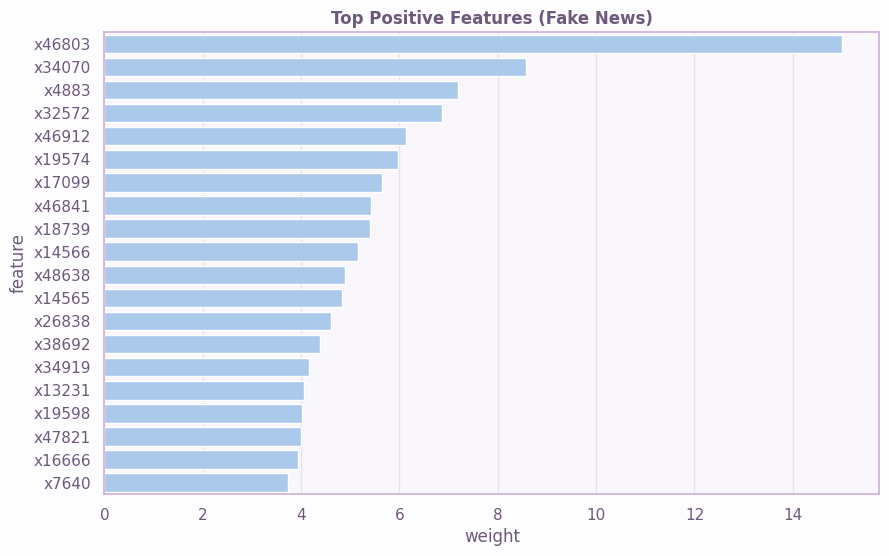

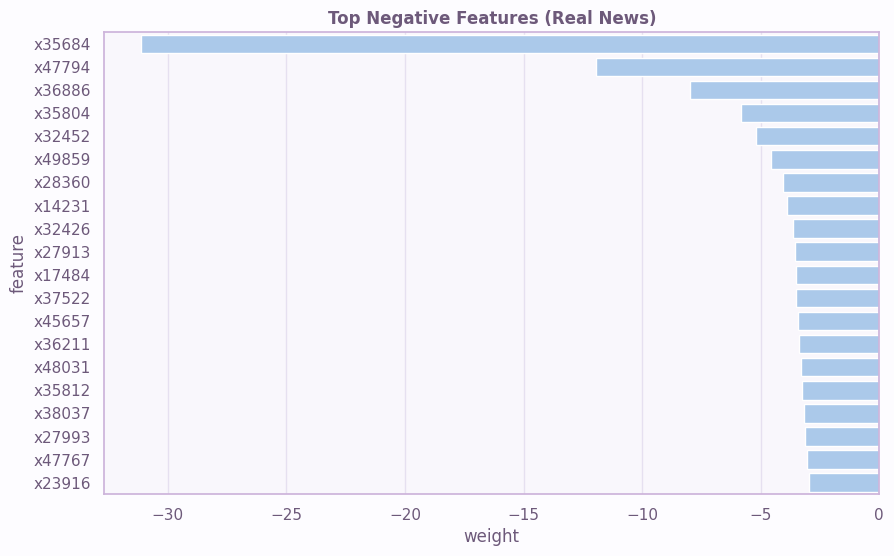

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="weight", y="feature", data=top_pos)
plt.title("Top Positive Features (Fake News)")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x="weight", y="feature", data=top_neg)
plt.title("Top Negative Features (Real News)")
plt.show()


# --- SHAP EXPLAINABILITY---

Enter news text for SHAP explanation: breaking news: donald trump is shot during speech at white house


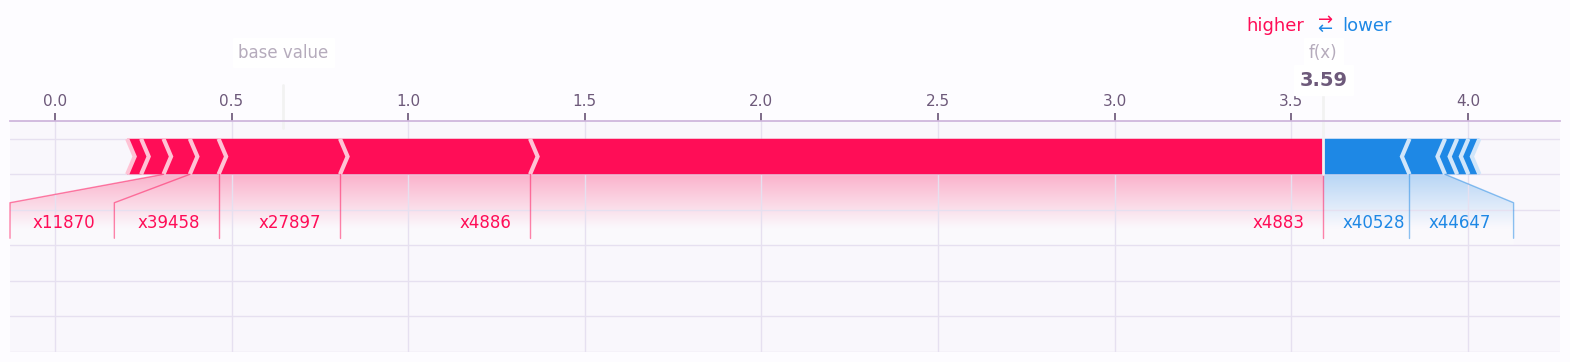

In [ ]:
explainer = shap.LinearExplainer(model, selector.transform(tfidf.transform(["sample text"]))) # dummy background
# Input your own text here
input_text = input("Enter news text for SHAP explanation: ")
cleaned_text = clean_text(input_text)
vec = tfidf.transform([cleaned_text])
vec_sel = selector.transform(vec)

# SHAP values
shap_values = explainer.shap_values(vec_sel)


shap.force_plot(
    explainer.expected_value,  # scalar
    shap_values,               # array
    feature_names,         # feature names
    matplotlib=True
)
